## Tumour identification pipeline

This implements the workflow:

1. Open a `.tif` (single image) or `.lif` (loop over contained images).
2. Extract pixel size from metadata, falling back to a user-supplied value.
3. Take a 2D slice from the requested channel (max-project the Z axis if a stack).
4. If `type="bf"`, invert the image so tumours appear bright on a dark background.
5. Rescale intensities to 0-255 (`uint8`).
6. Threshold to find a single bright region.
7. If the region has low eccentricity, split it with a watershed segmentation.
8. From the split regions, keep the one with the highest mean intensity in the
   rescaled image (this is the tumour).

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterator, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import tifffile
from liffile import LifFile

from scipy import ndimage as ndi
from skimage import util
from skimage.filters import gaussian, threshold_otsu, threshold_triangle, threshold_mean, threshold_minimum
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import (
    disk,
    binary_opening,
    remove_small_holes,
    remove_small_objects,
)
from skimage.segmentation import watershed, clear_border
from skimage.feature import peak_local_max

In [2]:
def rescale_intensity(img: np.ndarray, target_min: float = 0, target_max: float = 255, target_dtype=np.uint8,) -> np.ndarray:
    """Linearly rescale *img* intensity to ``[target_min, target_max]`` and cast."""
    imin, imax = float(img.min()), float(img.max())
    if imax == imin:
        return np.full_like(img, target_min, dtype=target_dtype)
    a = (target_max - target_min) / (imax - imin)
    b = target_max - a * imax
    return (a * img + b).astype(target_dtype)

In [3]:
def _tiff_pixel_size_um(tif: tifffile.TiffFile) -> Optional[Tuple[float, float]]:
    """Return (y_um_per_px, x_um_per_px) from TIFF metadata, if available."""
    page = tif.pages[0]
    tags = page.tags

    # ImageJ-style metadata.
    ij = getattr(tif, "imagej_metadata", None) or {}
    unit = (ij.get("unit") or "").lower()
    if "XResolution" in tags and "YResolution" in tags:
        def _res_to_um(res, unit_hint):
            num, den = res
            if num == 0:
                return None
            px_per_unit = num / den
            um_per_px = 1.0 / px_per_unit
            if unit_hint in ("cm",):
                um_per_px *= 1e4
            elif unit_hint in ("mm",):
                um_per_px *= 1e3
            elif unit_hint in ("inch", "in"):
                um_per_px *= 25_400.0
            # micron / um / "" assumed already in microns
            return um_per_px

        # Decide unit: prefer ImageJ, else ResolutionUnit tag.
        unit_hint = unit
        if not unit_hint and "ResolutionUnit" in tags:
            ru = tags["ResolutionUnit"].value
            unit_hint = {2: "inch", 3: "cm"}.get(int(ru), "")
        x_um = _res_to_um(tags["XResolution"].value, unit_hint)
        y_um = _res_to_um(tags["YResolution"].value, unit_hint)
        if x_um and y_um:
            return float(y_um), float(x_um)
    return None


def _xarray_axis_step(xa, axis: str) -> Optional[float]:
    """Coordinate spacing along ``axis`` in the xarray, or None if unavailable.

    Mirrors the helper used in placenta_permeability.py.
    """
    if axis not in xa.coords or xa.coords[axis].size < 2:
        return None
    return float(xa.coords[axis][1] - xa.coords[axis][0])


def _lif_pixel_size_um(image) -> Optional[Tuple[float, float]]:
    """Return (y_um_per_px, x_um_per_px) for a ``liffile`` image.

    Uses ``image.asxarray()`` coordinates, which ``liffile`` stores in metres.
    Converts to micrometres the same way placenta_permeability.py does
    (``step('X', xa) * 1e6``).
    """
    xa = image.asxarray()
    x_step = _xarray_axis_step(xa, "X")
    y_step = _xarray_axis_step(xa, "Y")
    if x_step is None or y_step is None:
        return None
    x_um = abs(x_step) * 1e6
    y_um = abs(y_step) * 1e6
    if x_um <= 0 or y_um <= 0:
        return None
    return y_um, x_um


def _extract_2d_slice(arr: np.ndarray, axes: str, channel_no: int) -> np.ndarray:
    """Select a 2D YX slice from an arbitrarily-axed array.

    Picks ``channel_no`` along the C axis (if present) and max-projects any Z/T
    axis so the result is a 2D image suitable for downstream segmentation.
    """
    axes = axes.upper()
    arr = np.asarray(arr)

    if len(axes) != arr.ndim:
        # Fallback: assume the last two dims are YX and the first is channel/Z.
        if arr.ndim == 2:
            return arr
        if arr.ndim == 3:
            return arr[min(channel_no, arr.shape[0] - 1)]
        # Collapse leading axes by taking channel from the first and max over rest.
        sub = arr[min(channel_no, arr.shape[0] - 1)]
        while sub.ndim > 2:
            sub = sub.max(axis=0)
        return sub

    # Channel selection.
    if "C" in axes:
        c_idx = axes.index("C")
        c = min(channel_no, arr.shape[c_idx] - 1)
        arr = np.take(arr, c, axis=c_idx)
        axes = axes.replace("C", "")

    # Collapse any Z / T axes by max-projection.
    for collapse in ("Z", "T"):
        while collapse in axes:
            i = axes.index(collapse)
            arr = arr.max(axis=i)
            axes = axes[:i] + axes[i + 1 :]

    while arr.ndim > 2:
        arr = arr.max(axis=0)
    return arr

In [4]:
def iter_images(
    file_path: Path,
    bf_channel: int = 0,
    fluorescent_channel: Optional[int] = None,
    fallback_pixel_size_um: Optional[float] = None,
) -> Iterator[Tuple[str, np.ndarray, Optional[np.ndarray], Tuple[float, float]]]:
    """Yield ``(name, bf_image_2d, fl_image_2d_or_None, (y_um, x_um))`` for each image.

    Handles ``.tif``/``.tiff`` (one image) and ``.lif`` (loops over contained
    images using the ``liffile`` library). ``bf_channel`` selects the brightfield
    channel; ``fluorescent_channel`` optionally selects a second channel (no
    inversion applied). Any Z/T axes are max-projected.
    """
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()
    fallback = (
        (float(fallback_pixel_size_um), float(fallback_pixel_size_um))
        if fallback_pixel_size_um is not None
        else None
    )

    if suffix in (".tif", ".tiff"):
        with tifffile.TiffFile(file_path) as tif:
            arr = tif.asarray()
            axes = (tif.series[0].axes or "").upper() or ("YX" if arr.ndim == 2 else "")
            pix = _tiff_pixel_size_um(tif) or fallback
            if pix is None:
                raise ValueError(
                    f"No pixel size in {file_path.name}; pass fallback_pixel_size_um."
                )
            bf_img2d = _extract_2d_slice(arr, axes, bf_channel)
            fl_img2d = (
                _extract_2d_slice(arr, axes, fluorescent_channel)
                if fluorescent_channel is not None
                else None
            )
            yield file_path.stem, bf_img2d, fl_img2d, pix
        return

    if suffix == ".lif":
        with LifFile(str(file_path)) as lif:
            for image in lif.images:
                axes = "".join(image.sizes.keys()).upper()
                arr = np.asarray(image.asarray())
                bf_img2d = _extract_2d_slice(arr, axes, bf_channel)
                fl_img2d = (
                    _extract_2d_slice(arr, axes, fluorescent_channel)
                    if fluorescent_channel is not None
                    else None
                )
                pix = _lif_pixel_size_um(image) or fallback
                if pix is None:
                    raise ValueError(
                        f"No pixel size in {file_path.name}:{image.name}; "
                        "pass fallback_pixel_size_um."
                    )
                yield f"{file_path.stem}__{image.name}", bf_img2d, fl_img2d, pix
        return

    raise ValueError(f"Unsupported file type: {suffix}")

In [5]:
def watershed_separation(binary: np.ndarray, pixel_size_um: float, min_separation_um: float = 30.0,) -> np.ndarray:
    """Split a touching binary blob into labelled regions via distance watershed."""
    distance = ndi.distance_transform_edt(binary)
    min_distance_px = max(3, int(round(min_separation_um / pixel_size_um)))
    coords = peak_local_max(distance, min_distance=min_distance_px, labels=binary.astype(np.int32))
    if len(coords) < 2:
        return label(binary)
    markers = np.zeros(binary.shape, dtype=np.int32)
    markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    return watershed(-distance, markers, mask=binary)


def identify_tumour(image_2d: np.ndarray, pixel_size_um: Tuple[float, float], image_type: str = "bf",
    max_eccentricity: float = 0.6, min_solidity: float = 0.9, min_object_area_um2: float = 5_000.0,
    watershed_separation_um: float = 10000.0,) -> dict:
    """Identify the tumour in a 2D image.

    Parameters
    ----------
    image_2d
        2D YX image (any dtype).
    pixel_size_um
        ``(y_um_per_px, x_um_per_px)`` from metadata.
    image_type
        ``"bf"`` (brightfield -> tumour is dark, image is inverted) or
        ``"fluorescent"`` (tumour is already bright).
    max_eccentricity
        If the initial region's eccentricity exceeds this (0 = circle, 1 = line),
        a watershed split is attempted.
    min_object_area_um2
        Minimum candidate area (used for cleanup and watershed filtering).
    watershed_separation_um
        Minimum distance between watershed seeds.

    Returns
    -------
    dict with keys ``rescaled``, ``mask``, ``label``, ``area_um2``,
    ``eccentricity``, ``mean_intensity``, ``split`` (bool).
    """
    if image_2d.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {image_2d.shape}")
    py, px = float(pixel_size_um[0]), float(pixel_size_um[1])
    area_per_px = py * px

    img = image_2d
    if image_type.lower() == "bf":
        img = util.invert(img)
    rescaled = rescale_intensity(img, 0, 255, np.uint8)

    # --- Identify the bright region ---------------------------------------
    smoothed = gaussian(rescaled, sigma=2, preserve_range=True)
    from skimage.filters import try_all_threshold
    try_all_threshold(smoothed)
    thresh = threshold_otsu(smoothed)
    binary = smoothed > thresh

    # min_area_px = max(1, int(round(min_object_area_um2 / area_per_px)))
    # binary = remove_small_holes(binary, area_threshold=min_area_px)
    # binary = remove_small_objects(binary, min_size=min_area_px)
    binary = binary_opening(binary, disk(3))
    # binary = clear_border(binary)

    labelled = label(binary)
    if labelled.max() == 0:
        return {
            "rescaled": rescaled,
            "mask": np.zeros_like(binary, dtype=bool),
            "label": None,
            "area_um2": 0.0,
            "eccentricity": 0.0,
            "mean_intensity": 0.0,
            "split": False,
        }

    # Pick the largest connected component as the initial candidate.
    props = regionprops(labelled, intensity_image=rescaled)
    props.sort(key=lambda p: p.area, reverse=True)
    candidate = props[0]
    candidate_mask = labelled == candidate.label
    # eccentricity: 0 = perfect circle, 1 = line segment (2D only, no extra call needed)
    eccentricity = float(candidate.eccentricity)
    solidity = float(candidate.solidity)
    print("INITIAL ECCENTRICITY {:.3f}".format(eccentricity))

    # --- Watershed split on high eccentricity (elongated / multiple blobs) ---
    split = False
    if (eccentricity > max_eccentricity) or (solidity < min_solidity):
        print("eccentricity {:.3f} and solidity {:.3f} - Attempting watershed split... ".format(eccentricity, solidity))
        ws = watershed_separation(candidate_mask, pixel_size_um=min(py, px), min_separation_um=watershed_separation_um)
        ws_props = regionprops(ws, intensity_image=rescaled)
        ws_props = [p for p in ws_props if p.area * area_per_px >= min_object_area_um2]
        if len(ws_props) >= 2:
            split = True
            # Select the sub-region with the highest mean intensity.
            best = max(ws_props, key=lambda p: p.mean_intensity)
            candidate_mask = ws == best.label
            candidate = best
            eccentricity = float(candidate.eccentricity)

    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))
    ax[0].imshow(rescaled, cmap='gray')
    ax[1].imshow(binary, cmap='gray')
    ax[2].imshow(label(candidate_mask), cmap='gray')
    plt.show()

    mean_int = float(rescaled[candidate_mask].mean())
    return {
        "rescaled": rescaled,
        "mask": candidate_mask,
        "label": int(getattr(candidate, "label", 1)),
        "area_um2": float(candidate.area * area_per_px),
        "eccentricity": eccentricity,
        "mean_intensity": mean_int,
        "split": split,
    }

In [6]:
def process_file(
    file_path: str | Path,
    bf_channel: int = 0,
    fluorescent_channel: Optional[int] = None,
    fallback_pixel_size_um: Optional[float] = None,
    show: bool = True,
    **identify_kwargs,
) -> list[dict]:
    """Process a single ``.tif`` or ``.lif`` file and return per-image results."""
    results = []
    for name, bf_img2d, fl_img2d, pix in iter_images(
        Path(file_path),
        bf_channel=bf_channel,
        fluorescent_channel=fluorescent_channel,
        fallback_pixel_size_um=fallback_pixel_size_um,
    ):
        bf_res = identify_tumour(bf_img2d, pixel_size_um=pix, image_type="bf", **identify_kwargs)
        fl_res = (
            identify_tumour(fl_img2d, pixel_size_um=pix, image_type="fluorescent", **identify_kwargs)
            if fl_img2d is not None
            else None
        )
        results.append({"name": name, "pixel_size_um": pix, "bf": bf_res, "fl": fl_res})

        if show:
            n = 4 if fl_res is not None else 2
            fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
            axes[0].imshow(bf_res["rescaled"], cmap="gray")
            axes[0].set_title(f"{name}\nBF rescaled")
            axes[0].axis("off")
            axes[1].imshow(bf_res["rescaled"], cmap="gray")
            if bf_res["mask"].any():
                axes[1].contour(bf_res["mask"], colors="red", linewidths=1.0)
            axes[1].set_title(f"BF  area={bf_res['area_um2']:.0f} um²  ecc={bf_res['eccentricity']:.2f}")
            axes[1].axis("off")
            if fl_res is not None:
                axes[2].imshow(fl_res["rescaled"], cmap="gray")
                axes[2].set_title("FL rescaled")
                axes[2].axis("off")
                axes[3].imshow(fl_res["rescaled"], cmap="gray")
                if fl_res["mask"].any():
                    axes[3].contour(fl_res["mask"], colors="cyan", linewidths=1.0)
                axes[3].set_title(f"FL  area={fl_res['area_um2']:.0f} um²  ecc={fl_res['eccentricity']:.2f}")
                axes[3].axis("off")
            plt.tight_layout()
            plt.show()

    return results

## Batch process a folder

Walk `INPUT_DIR` recursively, run the tumour identification on every `.tif`
and `.lif` (looping over images inside each `.lif`), and save a segmentation
overlay PNG plus a summary CSV under `OUTPUT_DIR`.

Found 33 input file(s) under Y:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Inputs

--- Seeding 1 2026.03.16\2026.05.14_Size_CART_batchPerm.lif ---


c:\Users\isobe\anaconda3\envs\imaging_record\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.422


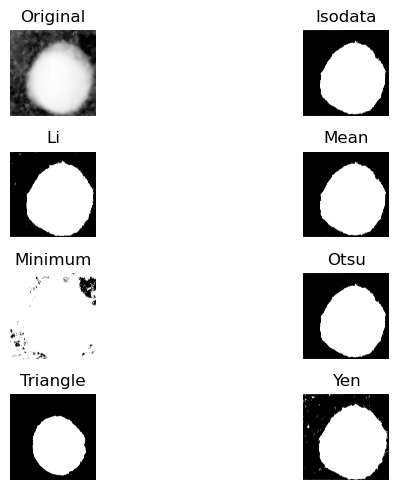

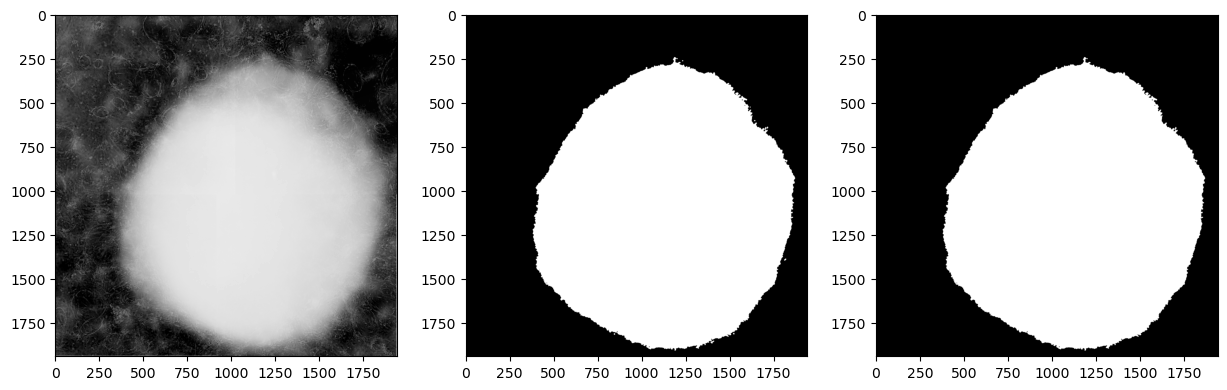

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device1  area=3042641 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.625
eccentricity 0.625 and solidity 0.949 - Attempting watershed split... 


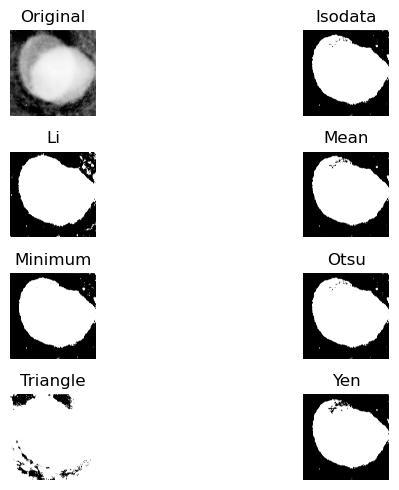

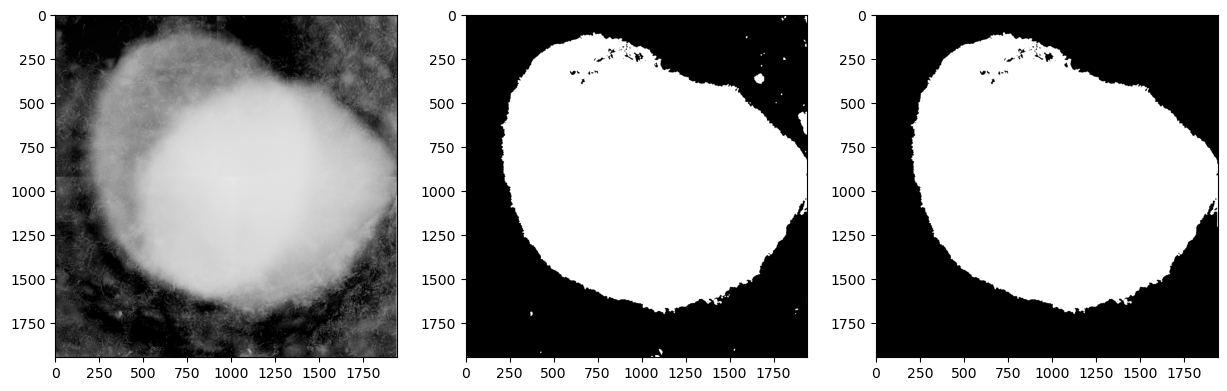

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device2  area=3309157 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.585


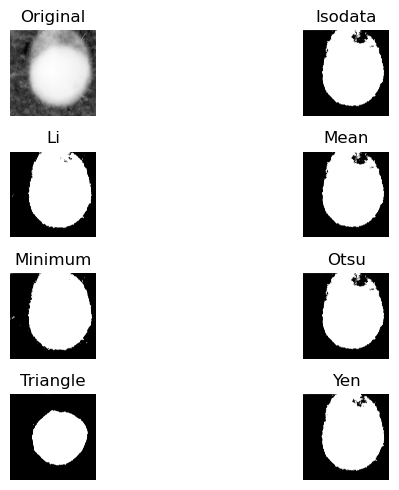

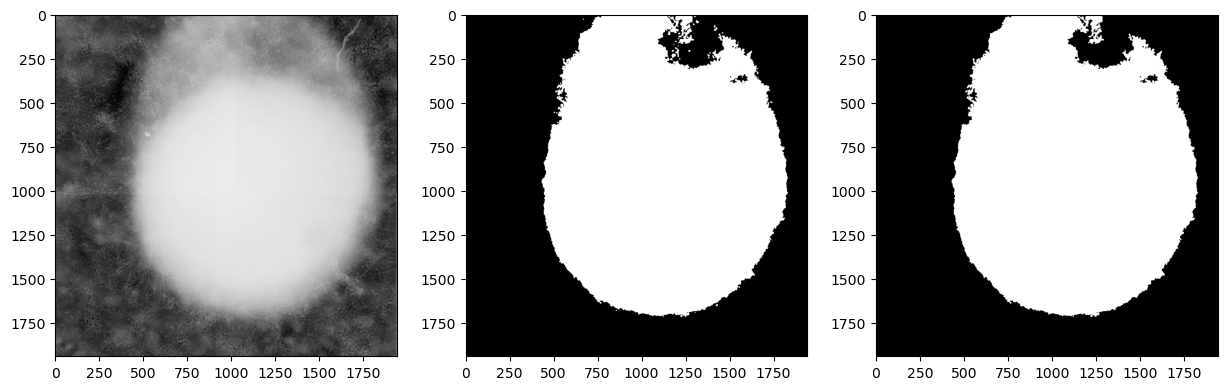

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device3  area=3106938 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.476


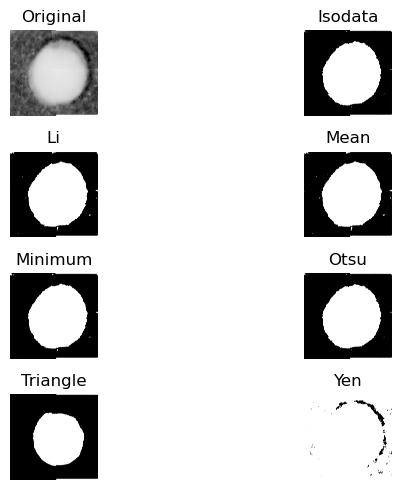

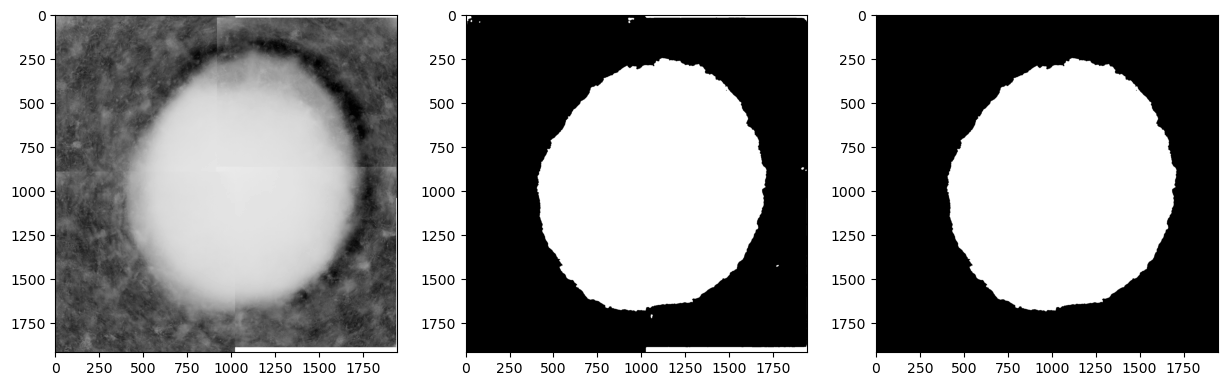

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device4  area=2389009 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.612
eccentricity 0.612 and solidity 0.754 - Attempting watershed split... 


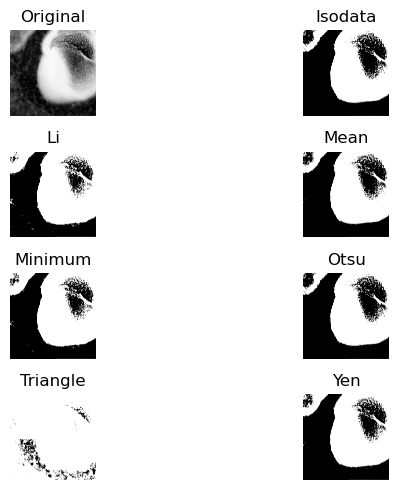

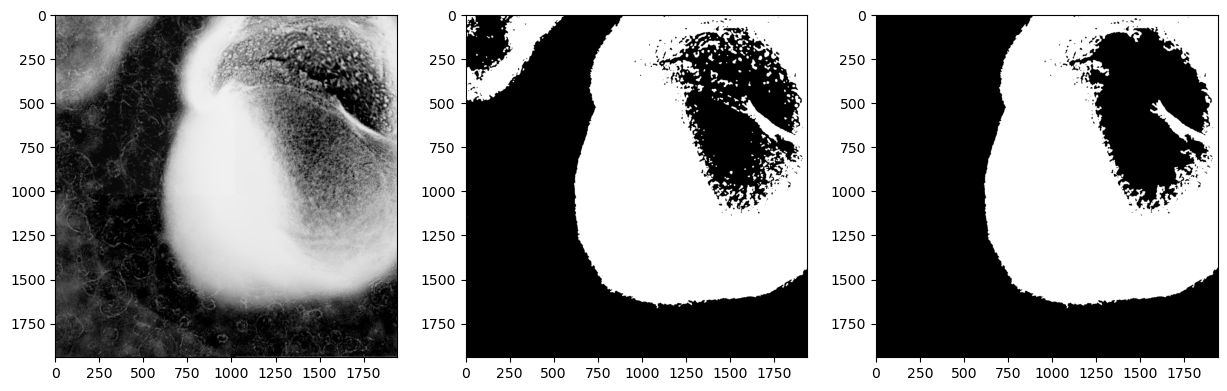

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device1  area=2565231 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.667
eccentricity 0.667 and solidity 0.912 - Attempting watershed split... 


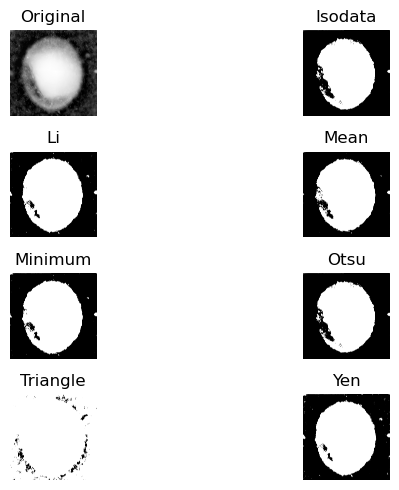

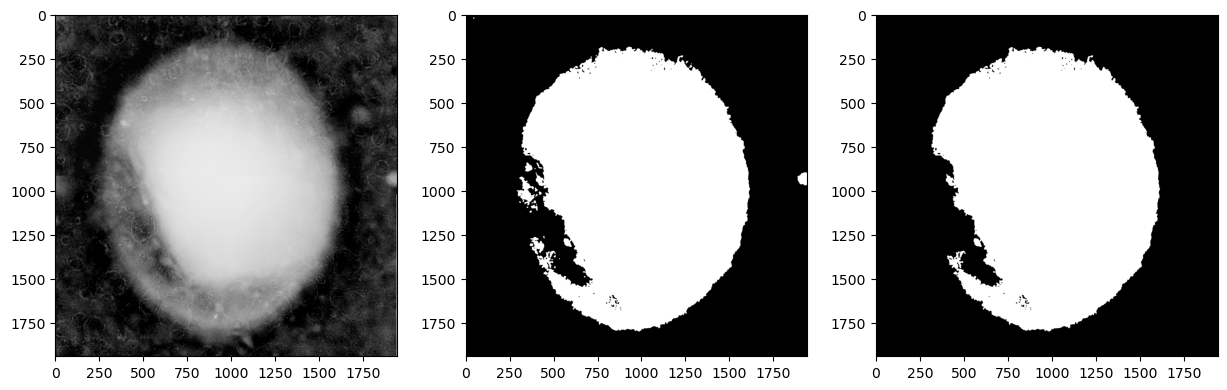

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device2  area=2548626 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.463
eccentricity 0.463 and solidity 0.741 - Attempting watershed split... 


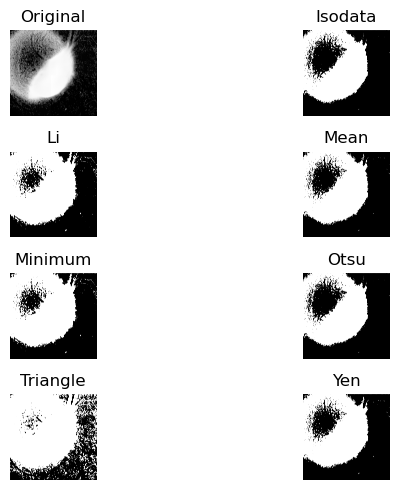

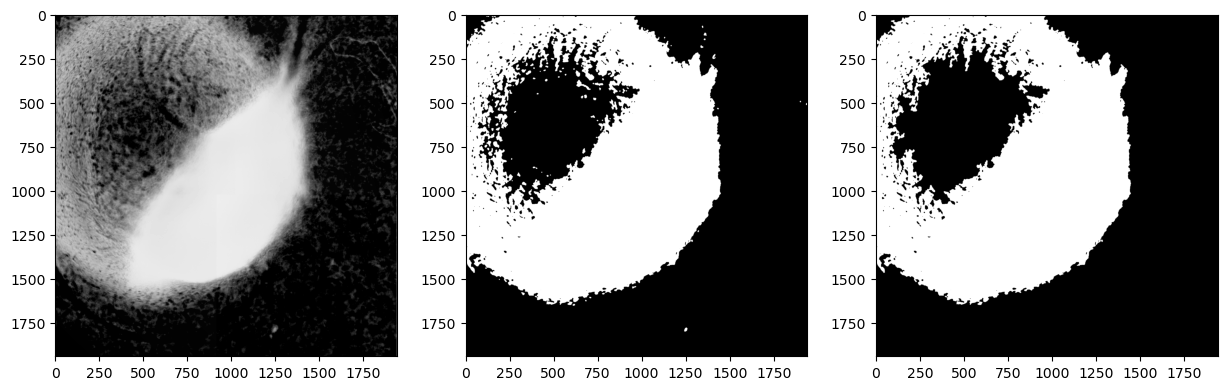

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device3  area=2613451 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.476


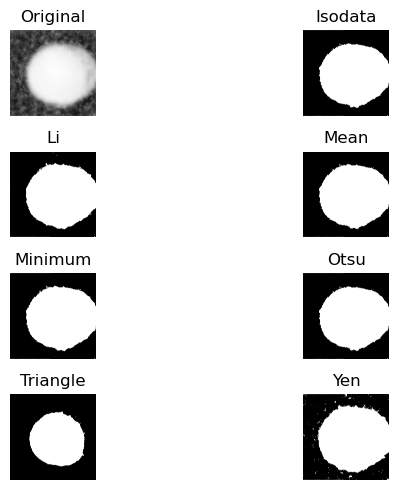

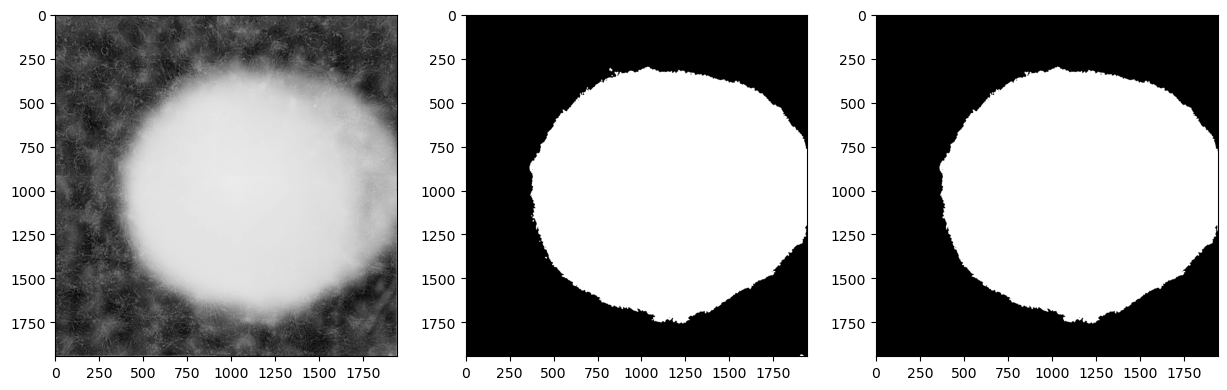

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device4  area=2978973 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.695
eccentricity 0.695 and solidity 0.957 - Attempting watershed split... 


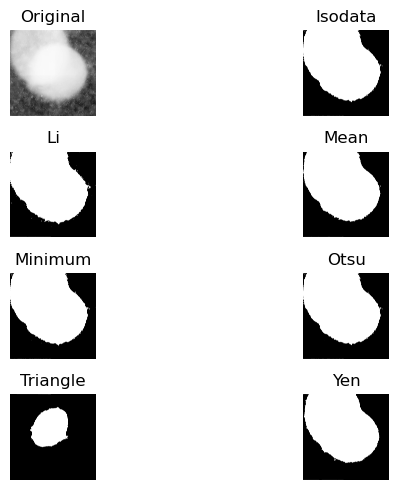

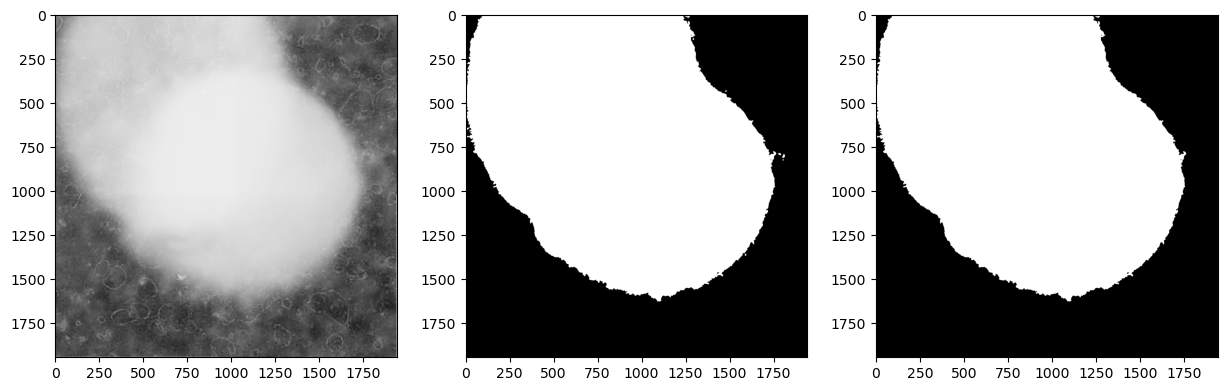

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL32_device1  area=3579161 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.706
eccentricity 0.706 and solidity 0.916 - Attempting watershed split... 


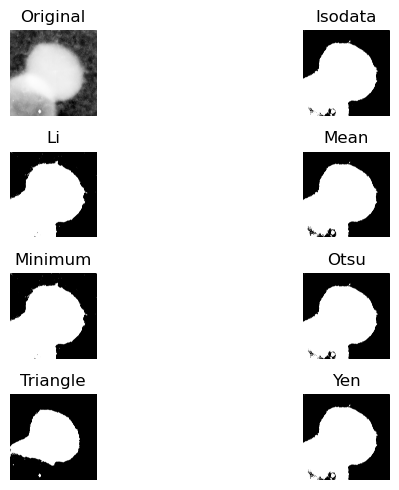

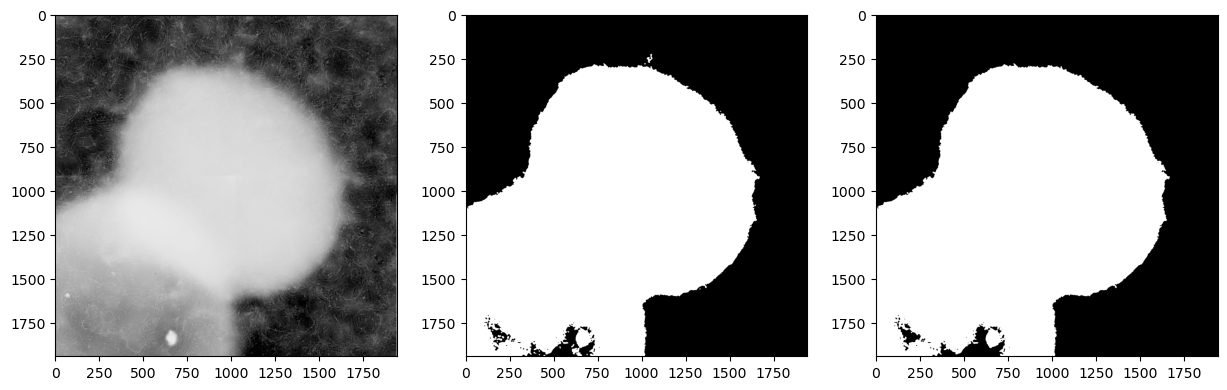

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL32_device2  area=3309245 um²
skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen
INITIAL ECCENTRICITY 0.717
eccentricity 0.717 and solidity 0.930 - Attempting watershed split... 


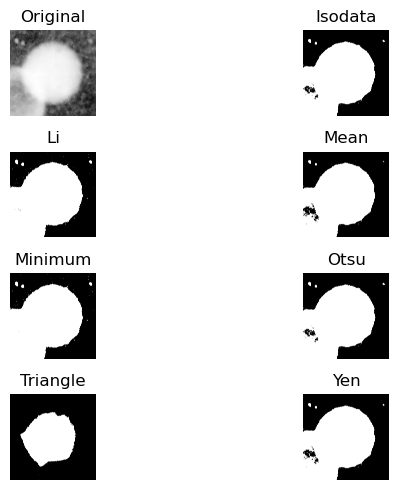

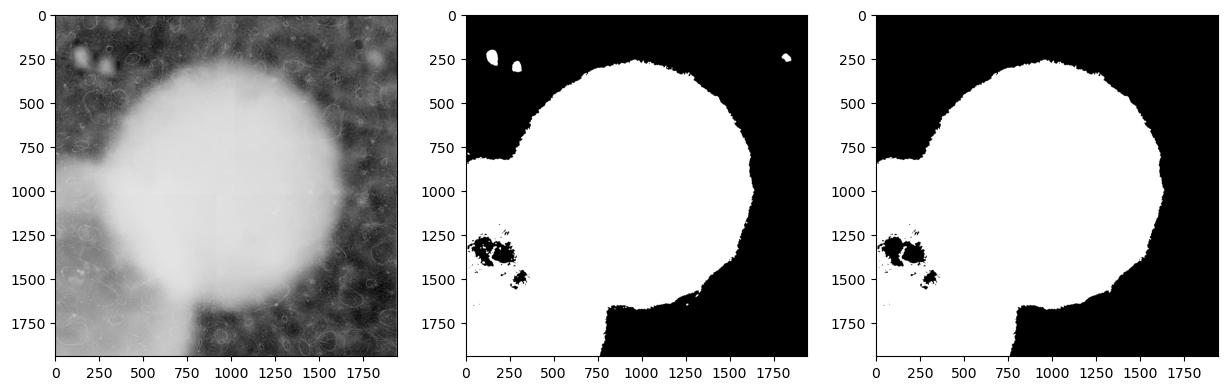

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL32_device3  area=3373444 um²


In [ ]:
import csv
import traceback

INPUT_DIR  = Path(r"Y:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Inputs")
OUTPUT_DIR = Path(r"Y:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs")

# ── Pipeline parameters (edit as needed) ──────────────────────────────────────
BF_CHANNEL           = 0     # brightfield channel index
FLUORESCENT_CHANNEL  = None  # set to an int (e.g. 1) to also segment a fluorescence channel
FALLBACK_PIXEL_SIZE_UM = None  # e.g. 0.65 — used only when metadata has no pixel size
# ──────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _safe_name(s: str) -> str:
    """Strip characters that are illegal in Windows file names."""
    return "".join("_" if c in '<>:"/\\|?*' else c for c in s).strip().strip(".")


def _save_segmentation_png(
    name: str,
    bf_res: Optional[dict],
    fl_res: Optional[dict],
    out_path: Path,
) -> None:
    """Save a combined segmentation overlay PNG (BF + optional FL)."""
    n = 4 if fl_res is not None else 2
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))

    if bf_res is not None:
        axes[0].imshow(bf_res["rescaled"], cmap="gray")
        axes[0].set_title(f"{name}\nBF rescaled")
        axes[0].axis("off")
        axes[1].imshow(bf_res["rescaled"], cmap="gray")
        if bf_res["mask"].any():
            axes[1].contour(bf_res["mask"], colors="red", linewidths=1.0)
        axes[1].set_title(
            f"BF  area={bf_res['area_um2']:.0f} um²  "
            f"ecc={bf_res['eccentricity']:.2f}  split={bf_res['split']}"
        )
        axes[1].axis("off")

    if fl_res is not None:
        axes[2].imshow(fl_res["rescaled"], cmap="gray")
        axes[2].set_title("FL rescaled")
        axes[2].axis("off")
        axes[3].imshow(fl_res["rescaled"], cmap="gray")
        if fl_res["mask"].any():
            axes[3].contour(fl_res["mask"], colors="cyan", linewidths=1.0)
        axes[3].set_title(
            f"FL  area={fl_res['area_um2']:.0f} um²  "
            f"ecc={fl_res['eccentricity']:.2f}  split={fl_res['split']}"
        )
        axes[3].axis("off")

    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


# ── Main batch loop ────────────────────────────────────────────────────────────
input_files = sorted(
    p for p in INPUT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in (".tif", ".tiff", ".lif")
)
print(f"Found {len(input_files)} input file(s) under {INPUT_DIR}")

for file_path in input_files:
    rel_parent = file_path.relative_to(INPUT_DIR).parent
    out_subdir = OUTPUT_DIR / rel_parent / file_path.stem
    out_subdir.mkdir(parents=True, exist_ok=True)
    csv_path = out_subdir / f"{file_path.stem}_results.csv"

    print(f"\n--- {file_path.relative_to(INPUT_DIR)} ---")
    file_rows: list[dict] = []

    try:
        for name, bf_img2d, fl_img2d, pix in iter_images(
            file_path,
            bf_channel=BF_CHANNEL,
            fluorescent_channel=FLUORESCENT_CHANNEL,
            fallback_pixel_size_um=FALLBACK_PIXEL_SIZE_UM,
        ):
            y_um, x_um = pix
            area_per_px = y_um * x_um

            row = {
                "image_name":       name,
                "x_um_per_px":      x_um,
                "y_um_per_px":      y_um,
                "bf_area_px2":      None,
                "bf_area_um2":      None,
                "fl_area_px2":      None,
                "fl_area_um2":      None,
                "bf_eccentricity":  None,
                "fl_eccentricity":  None,
                "bf_split":         None,
                "fl_split":         None,
                "bf_error":         "",
                "fl_error":         "",
            }

            bf_res, fl_res = None, None

            # ── Brightfield segmentation ──
            try:
                bf_res = identify_tumour(bf_img2d, pixel_size_um=pix, image_type="bf")
                row["bf_area_px2"]     = round(bf_res["area_um2"] / area_per_px) if area_per_px > 0 else None
                row["bf_area_um2"]     = round(bf_res["area_um2"], 2)
                row["bf_eccentricity"] = round(bf_res["eccentricity"], 4)
                row["bf_split"]        = bf_res["split"]
                print(f"  BF OK  {name}  area={bf_res['area_um2']:.0f} um²")
            except Exception as e:
                row["bf_error"] = f"{type(e).__name__}: {e}"
                print(f"  BF ERR {name}: {e}")

            # ── Fluorescence segmentation (optional) ──
            if fl_img2d is not None:
                try:
                    fl_res = identify_tumour(fl_img2d, pixel_size_um=pix, image_type="fluorescent")
                    row["fl_area_px2"]     = round(fl_res["area_um2"] / area_per_px) if area_per_px > 0 else None
                    row["fl_area_um2"]     = round(fl_res["area_um2"], 2)
                    row["fl_eccentricity"] = round(fl_res["eccentricity"], 4)
                    row["fl_split"]        = fl_res["split"]
                    print(f"  FL OK  {name}  area={fl_res['area_um2']:.0f} um²")
                except Exception as e:
                    row["fl_error"] = f"{type(e).__name__}: {e}"
                    print(f"  FL ERR {name}: {e}")

            # ── Save PNG ──
            if bf_res is not None or fl_res is not None:
                png_path = out_subdir / f"{_safe_name(name)}_segmentation.png"
                try:
                    _save_segmentation_png(name, bf_res, fl_res, png_path)
                except Exception as e:
                    print(f"  PNG ERR {name}: {e}")

            file_rows.append(row)

    except Exception as e:
        print(f"  FAILED to open {file_path.name}: {e}")
        traceback.print_exc()
        file_rows.append({
            "image_name": "", "x_um_per_px": None, "y_um_per_px": None,
            "bf_area_px2": None, "bf_area_um2": None,
            "fl_area_px2": None, "fl_area_um2": None,
            "bf_eccentricity": None, "fl_eccentricity": None,
            "bf_split": None, "fl_split": None,
            "bf_error": f"{type(e).__name__}: {e}", "fl_error": "",
        })

    # ── Write per-file CSV ──
    if file_rows:
        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(file_rows[0].keys()))
            writer.writeheader()
            writer.writerows(file_rows)
        print(f"  CSV saved: {csv_path}  ({len(file_rows)} row(s))")